#Use case : Statistics for Hospital Patient Treatment Analysis

#Lab Title

Using Probability and Statistical Tests to Evaluate Hospital Treatment Outcomes

#Learning Objective

Students learn how probability and statistical testing support decision-making in healthcare analytics, such as evaluating treatment effectiveness and patient behavior.

#Scenario

A hospital wants to evaluate whether treatment methods, patient conditions, and medication types influence recovery rates and treatment costs.

Data scientists must analyze patient records to answer:

> Does a specific treatment improve recovery?

> Do different treatment groups have different recovery costs?

> Are patient conditions related to treatment outcomes?

Students will analyze synthetic hospital patient data.

#Dataset Creation



In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    "Patient_ID": range(1,101),
    "Recovered": np.random.choice(["Yes","No"],100),
    "Treatment_Type": np.random.choice(["Medication","Therapy","Surgery"],100),
    "Disease_Type": np.random.choice(["Cardiac","Diabetes","Respiratory"],100),
    "Insurance": np.random.choice(["Yes","No"],100),
    "Treatment_Cost": np.random.normal(50000,10000,100)
}

df = pd.DataFrame(data)
df.head()

,Patient_ID,Recovered,Treatment_Type,Disease_Type,Insurance,Treatment_Cost
0,1,Yes,Surgery,Diabetes,No,49884.166802
1,2,No,Therapy,Diabetes,No,51905.987051
2,3,Yes,Therapy,Respiratory,Yes,56069.757096
3,4,Yes,Therapy,Diabetes,No,46510.988172
4,5,Yes,Therapy,Respiratory,Yes,56061.293631


#Activity 1 — Probability Fundamentals (5 minutes)
Question

What is the probability that a patient recovers after treatment?

In [2]:
# Probability of recovery

total_patients = len(df)

recovered = len(df[df["Recovered"]=="Yes"])

prob_recovery = recovered / total_patients

print("Probability of Recovery =", round(prob_recovery,3))
print(f"P(Recovery) = {recovered}/{total_patients}")

Probability of Recovery = 0.44
P(Recovery) = 44/100


#Learning

P(Recovery) = Patients recovered / Total patients

#Real World Impact

If recovery probability is low → hospital must review treatment protocols.

#Activity 2 — Independent vs Dependent Events (10 minutes)
Question

Is recovery dependent on treatment type?

In [4]:
# TYPE CODE# Conditional probability

prob_total = (
    df["Recovered"]=="Yes"
).mean()

print("Overall Recovery Probability:",round(prob_total,3))

for t in df["Treatment_Type"].unique():

    subset = df[df["Treatment_Type"]==t]

    prob = (subset["Recovered"]=="Yes").mean()

    print(f"P(Recovery | {t}) = {round(prob,3)}")

Overall Recovery Probability: 0.44
P(Recovery | Surgery) = 0.436
P(Recovery | Therapy) = 0.538
P(Recovery | Medication) = 0.371


# Activity 2 — Independent vs Dependent Events (10 minutes) Question

#Is recovery dependent on treatment type?

In [8]:
# Conditional probability

prob_total = (
    df["Recovered"]=="Yes"
).mean()

print("Overall Recovery Probability:",round(prob_total,3))

for t in df["Treatment_Type"].unique():

    subset = df[df["Treatment_Type"]==t]

    prob = (subset["Recovered"]=="Yes").mean()

    print(f"P(Recovery | {t}) = {round(prob,3)}")

Overall Recovery Probability: 0.44
P(Recovery | Surgery) = 0.436
P(Recovery | Therapy) = 0.538
P(Recovery | Medication) = 0.371


#Interpretation

If recovery probability differs across treatments → events are dependent.

#Real World Impact

Hospital can identify most effective treatment strategy.

#Activity 3 — Mutually Exclusive Events (10 minutes)
Question

A patient can receive only one treatment type in this dataset.

Events:

A = Surgery

B = Medication

Since a patient cannot receive both simultaneously

P(A ∩ B) = 0

#Learning

These events are mutually exclusive.

#Activity 4 — Hypothesis Testing (15 minutes)
Business Question

Does treatment type influence patient recovery?

Define:

H₀: Treatment type does not affect recovery

H₁: Treatment type affects recovery

Students learn how to frame data-driven hypotheses.

#Activity 5 — One Tail vs Two Tail Tests (10 minutes)
#Scenario

Hospital management believes:

> Surgery has higher recovery rate than medication.

Students identify this as One-Tail Test.

If question is:

Is there any difference between treatments?

→ Two-Tail Test.

#Activity 6 — Chi-Square Test (20 minutes)

Test relationship between Treatment Type and Recovery

In [9]:
print("H0: Treatment type does not affect recovery")

print("H1: Treatment type affects recovery")

alpha = 0.05

H0: Treatment type does not affect recovery
H1: Treatment type affects recovery


In [11]:
#Activity 6 — Chi-Square Test (20 minutes)

#Test relationship between Treatment Type and Recovery

In [12]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df["Treatment_Type"],
    df["Recovered"]
)

print(table)

chi2, p, dof, expected = chi2_contingency(table)

print("\nChi-Square Statistic =", round(chi2,3))
print("P-value =", round(p,4))

if p < 0.05:
    print("Reject H0")
    print("Treatment type significantly affects recovery")
else:
    print("Fail to Reject H0")
    print("No significant relationship")

Recovered       No  Yes
Treatment_Type         
Medication      22   13
Surgery         22   17
Therapy         12   14

Chi-Square Statistic = 1.694
P-value = 0.4288
Fail to Reject H0
No significant relationship


In [13]:
expected_df = pd.DataFrame(
    expected,
    columns=table.columns,
    index=table.index
)

print("\nExpected Frequencies")
print(expected_df)


Expected Frequencies
Recovered          No    Yes
Treatment_Type              
Medication      19.60  15.40
Surgery         21.84  17.16
Therapy         14.56  11.44


#Student Task

Interpret results.

If p < 0.05

→ Treatment type significantly affects recovery.

#Business Impact

Helps hospitals adopt most effective treatment method.

#Activity 7 — ANOVA (20 minutes)
Business Question

Do different treatments lead to different treatment costs?

In [14]:
from scipy.stats import f_oneway

med = df[df["Treatment_Type"]=="Medication"]["Treatment_Cost"]

ther = df[df["Treatment_Type"]=="Therapy"]["Treatment_Cost"]

surg = df[df["Treatment_Type"]=="Surgery"]["Treatment_Cost"]

f_stat, p = f_oneway(
    med,
    ther,
    surg
)

print("F-statistic =", round(f_stat,3))
print("P-value =", round(p,4))

if p < 0.05:
    print("Reject H0")
    print("Treatment costs differ significantly")
else:
    print("Fail to Reject H0")
    print("Treatment costs are statistically similar")

F-statistic = 0.791
P-value = 0.4562
Fail to Reject H0
Treatment costs are statistically similar


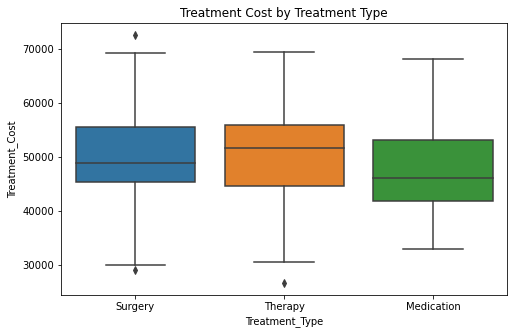

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Treatment_Type",
    y="Treatment_Cost"
)

plt.title("Treatment Cost by Treatment Type")

plt.show()

#Interpretation

If p < 0.05

→ Treatment costs significantly differ across groups.

# Business Impact

Hospitals can evaluate cost efficiency of treatments.

#Final Reflection Discussion (5 minutes)

Students answer:

> Why do hospitals need probability in decision making?

> Why must medical research use hypothesis testing?

> How do statistical tests improve healthcare decisions?

#Key Learning Outcomes

Students learn:

> Probability helps measure uncertainty in real-world events

> Event relationships explain dependencies in data

> Hypothesis testing validates medical or business assumptions

> Chi-Square finds relationships between categorical variables

> ANOVA compares multiple groups statistically